In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from astropy.wcs import WCS
from astropy.io import fits
import os
import math

In [2]:
def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

In [3]:
hdulist = fits.open('../data/2015_02_CalTauPer_toBernsteinCooper.fits')
hdu = hdulist[0]
wcs = WCS(hdu.header)

In [4]:
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 64.1175994873  38.8719177246  
CRPIX : 537.0  698.0  
NAXIS : 1179  911

In [5]:
phase_centers_ra = ['03:32:05', '03:25:30', '03:34:30', '03:36:00', '03:23:30']
phase_centers_dec = ['+31:05:04', '+29:29:60', '+31:59:60', '+30:30:00', '+31:30:00']

In [6]:
phase_centers_ra = np.array(phase_centers_ra)
phase_centers_dec = np.array(phase_centers_dec)

RA=[]
DEC=[]
for i in range(phase_centers_ra.shape[0]):
    radec=ra_dec_to_degrees(phase_centers_ra[i], phase_centers_dec[i])
    RA.append(radec[0])
    DEC.append(radec[1])

RA = np.array(RA)
DEC = np.array(DEC)
print(RA)
print(DEC)

[53.02083333 51.375      53.625      54.         50.875     ]
[31.08444444 29.5        32.         30.5        31.5       ]


In [7]:
x=[]
y=[]

for i in range(5):
    pixelRow, pixelColumn = wcs.wcs_world2pix(RA[i], DEC[i], 0)
    x.append(pixelRow)
    y.append(pixelColumn)

In [8]:
x

[array(922.13676581),
 array(989.60053264),
 array(896.51313627),
 array(890.36823497),
 array(995.54685742)]

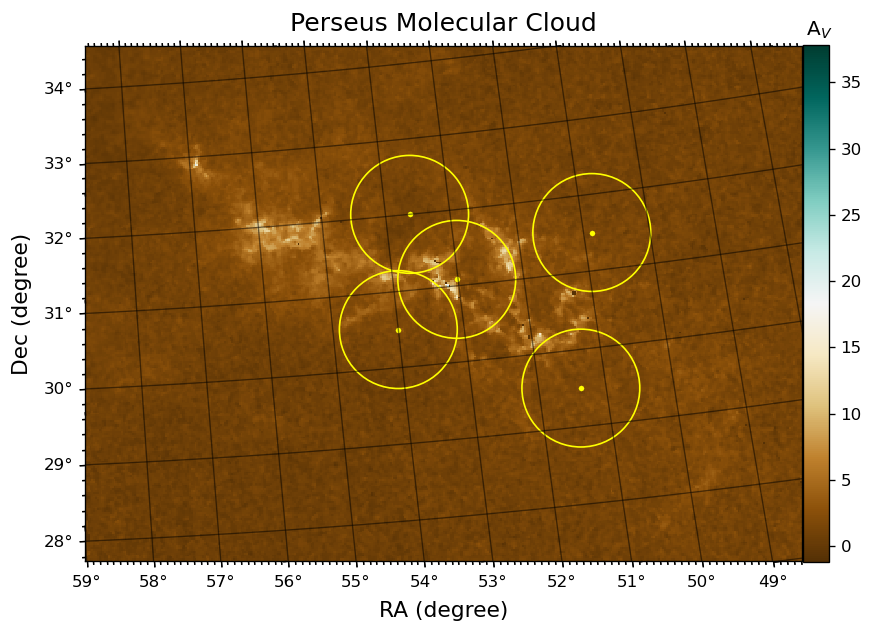

In [9]:
fig = plt.figure(figsize=(8, 8), dpi=120, facecolor='w', edgecolor='k')
ax = fig.add_subplot(111, projection=wcs)


colourMap = cm.get_cmap("BrBG")
ax.patch.set_facecolor(colourMap(-1))


plt.title('Perseus Molecular Cloud', fontsize=15, y=1.01)
im = plt.imshow(hdu.data, origin='lower', cmap=colourMap, interpolation='nearest')
plt.scatter(x,y, facecolor='none', edgecolors='yellow', s=5000, linewidth=1)
plt.scatter(x,y, facecolor='yellow', s=10, linewidth=0.1)


if not math.isnan(1110) and not math.isnan(720):
    ax.set_xlim(720, 1110)
if not math.isnan(530) and not math.isnan(250):
    ax.set_ylim(250, 530)

    
ra = ax.coords[0]
dec = ax.coords[1]
ra.set_major_formatter('d')
dec.set_major_formatter('d')
ra.set_axislabel('RA (degree)', fontsize=13)
dec.set_axislabel('Dec (degree)', fontsize=13)

dec.set_ticks(number=10)
ra.set_ticks(number=20)
ra.display_minor_ticks(True)
dec.display_minor_ticks(True)
ra.set_minor_frequency(10)

ra.grid(color='black', alpha=0.5, linestyle='solid')
dec.grid(color='black', alpha=0.5, linestyle='solid')       


cb = plt.colorbar(im, ticklocation='right', fraction=0.0347, pad=0.001115)
cb.ax.set_title(' A' + r'$_V$', linespacing=0.5, fontsize=12)
# ax.scatter(RA, DEC, marker='o', facecolor='red', linewidth=.5)
plt.savefig('./PerseusMolecularCloud', bbox_inches='tight')